In [1]:
import warnings
warnings.filterwarnings("ignore")

In [2]:
import pandas as pd
import numpy as np
import yfinance as yf
import datetime as dt

In [3]:
stk_data = yf.download("RELIANCE.NS", start="2023-01-01", end="2023-07-01")

[*********************100%***********************]  1 of 1 completed


In [4]:
stk_data

Price,Close,High,Low,Open,Volume
Ticker,RELIANCE.NS,RELIANCE.NS,RELIANCE.NS,RELIANCE.NS,RELIANCE.NS
Date,,,,,
2023-01-02,1175.889648,1177.304802,1163.244669,1164.066352,5316175
2023-01-03,1167.284668,1174.565828,1163.062148,1170.936659,7658932
2023-01-04,1149.709595,1169.110728,1147.632506,1167.261851,9264891
2023-01-05,1147.655396,1157.858149,1143.067616,1151.969321,13637099
2023-01-06,1158.086304,1163.130627,1149.595501,1153.407240,6349597
...,...,...,...,...,...
2023-06-23,1147.974976,1156.488600,1146.719570,1154.434333,6628570
2023-06-26,1139.210083,1148.271535,1136.083100,1144.436976,12641159


In [5]:
# The dataframe is not normal columns, it’s a MultiIndex (two-level columns).
# So, flattening the columns:

stk_data.columns = stk_data.columns.get_level_values(0)

In [6]:
stk_data

Price,Close,High,Low,Open,Volume
Date,,,,,
2023-01-02,1175.889648,1177.304802,1163.244669,1164.066352,5316175
2023-01-03,1167.284668,1174.565828,1163.062148,1170.936659,7658932
2023-01-04,1149.709595,1169.110728,1147.632506,1167.261851,9264891
2023-01-05,1147.655396,1157.858149,1143.067616,1151.969321,13637099
2023-01-06,1158.086304,1163.130627,1149.595501,1153.407240,6349597
...,...,...,...,...,...
2023-06-23,1147.974976,1156.488600,1146.719570,1154.434333,6628570
2023-06-26,1139.210083,1148.271535,1136.083100,1144.436976,12641159
2023-06-27,1139.621094,1145.578264,1135.147420,1139.666736,9689466


In [7]:
stk_data=stk_data[["Open", "High", "Low", "Close"]]

In [8]:
stk_data

Price,Open,High,Low,Close
Date,,,,
2023-01-02,1164.066352,1177.304802,1163.244669,1175.889648
2023-01-03,1170.936659,1174.565828,1163.062148,1167.284668
2023-01-04,1167.261851,1169.110728,1147.632506,1149.709595
2023-01-05,1151.969321,1157.858149,1143.067616,1147.655396
2023-01-06,1153.407240,1163.130627,1149.595501,1158.086304
...,...,...,...,...
2023-06-23,1154.434333,1156.488600,1146.719570,1147.974976
2023-06-26,1144.436976,1148.271535,1136.083100,1139.210083
2023-06-27,1139.666736,1145.578264,1135.147420,1139.621094


In [9]:
column="Close"

In [10]:
from sklearn.preprocessing import MinMaxScaler
Ms = MinMaxScaler()
data1 = Ms.fit_transform(stk_data[[column]])
print("Len:", data1.shape)

Len: (122, 1)


In [11]:
len(data1)

122

### Train - Test Split

In [12]:
training_size = round(len(data1) * 0.95)
print(training_size)

X_train = data1[:training_size]
X_test = data1[training_size:]
print("X_train length:", X_train.shape)
print("X_test length:", X_test.shape)

y_train = data1[:training_size]
y_test = data1[training_size:]
print("y_train length:", y_train.shape)
print("y_test length:", y_test.shape)

116
X_train length: (116, 1)
X_test length: (6, 1)
y_train length: (116, 1)
y_test length: (6, 1)


### Model Creation

#### ARMA Model

In [13]:
from sklearn.metrics import mean_squared_error
from statsmodels.tsa.arima.model import ARIMA
from stockFunctions import rmsemape  

orders = [(1,0,2), (1,0,1), (2,0,1), (1,0,1)]

for i in orders:
    from statsmodels.tsa.arima.model import ARIMA

    # Build model
    model = ARIMA(data1, order=i)
    model_fit = model.fit()

    # Make prediction
    y_pred = model_fit.predict(start=0, end=len(data1)-1)

    from stockFunctions import rmsemape
    print("Order:", i)
    rmsemape(data1, y_pred)
    print("************")

Order: (1, 0, 2)
RMSE-Testset: 0.07352646824220709
MAPE-Testset: 2862643957720.708
************
Order: (1, 0, 1)
RMSE-Testset: 0.07340570182667419
MAPE-Testset: 2843913639440.8115
************
Order: (2, 0, 1)
RMSE-Testset: 0.07344441091739991
MAPE-Testset: 2847488345558.3853
************
Order: (1, 0, 1)
RMSE-Testset: 0.07340570182667419
MAPE-Testset: 2843913639440.8115
************


In [14]:
len(y_pred)

122

In [17]:
from statsmodels.tsa.arima.model import ARIMA
from stockFunctions import rmsemape

# Best model
i = (2,0,1)

# Build model
model = ARIMA(X_train, order=i)
model_fit = model.fit()

# Make prediction
y_pred = model_fit.predict(start=training_size, end=len(data1)-1)

# Print results
print("Order:", i)
rmsemape(y_test, y_pred)
print("************")

Order: (2, 0, 1)
RMSE-Testset: 0.09585314958786786
MAPE-Testset: 0.10849687033056739
************


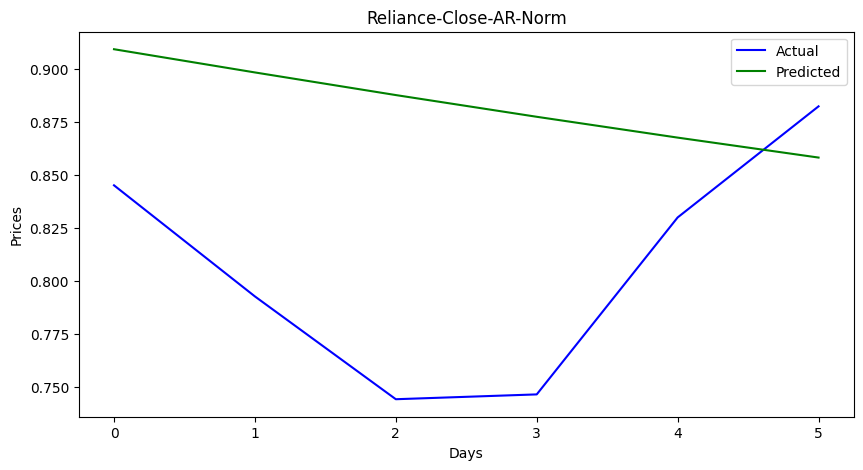

In [18]:
from stockFunctions import graph
graph(y_test, y_pred, "Actual", "Predicted", "Reliance-Close-AR-Norm", "Days", "Prices")

In [19]:
len(data1)

122

In [20]:
y_test

array([[0.84502627],
       [0.79256838],
       [0.74402745],
       [0.74630367],
       [0.82985799],
       [0.88231655]])

### Coverting to original data

In [21]:
from stockFunctions import conversionSingle
aTestNormTable = conversionSingle(y_test, [column])

In [22]:
aTestNormTable

,Close
0,0.845026
1,0.792568
2,0.744027
3,0.746304
4,0.829858
5,0.882317


In [23]:
actual_stock_price_test_ori = Ms.inverse_transform(aTestNormTable)

In [24]:
actual_stock_price_test_ori

array([[1157.44714355],
       [1147.97497559],
       [1139.21008301],
       [1139.62109375],
       [1154.70825195],
       [1164.18054199]])

In [25]:
actual_stock_price_test_oriA = conversionSingle(actual_stock_price_test_ori, [column])

In [26]:
actual_stock_price_test_oriA

,Close
0,1157.447144
1,1147.974976
2,1139.210083
3,1139.621094
4,1154.708252
5,1164.180542


In [27]:
from stockFunctions import conversionSingle

aTestNormTable = conversionSingle(y_test, [column])
actual_stock_price_test_ori = Ms.inverse_transform(aTestNormTable)
actual_stock_price_test_oriA = conversionSingle(actual_stock_price_test_ori, [column])

In [28]:
from stockFunctions import conversionSingle

pTestNormTable = conversionSingle(y_pred, [column])
predicted_stock_price_test_ori = Ms.inverse_transform(pTestNormTable)
predicted_stock_price_test_oriP = conversionSingle(predicted_stock_price_test_ori, [column])

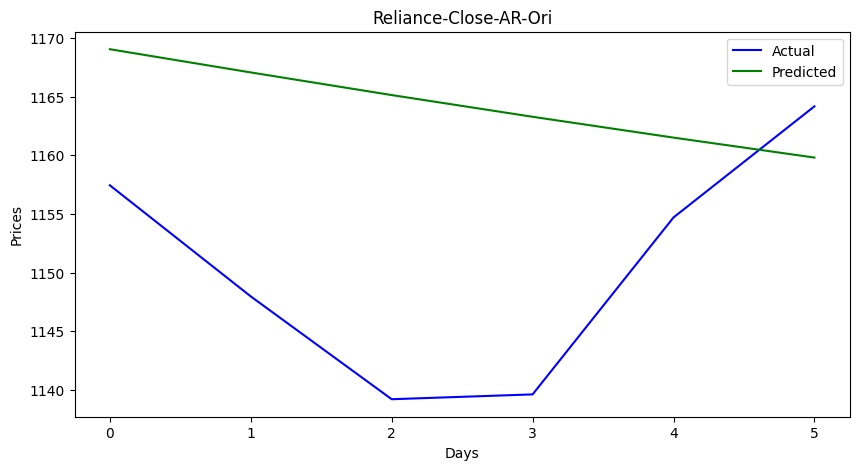

In [29]:
from stockFunctions import graph

graph(actual_stock_price_test_oriA,
      predicted_stock_price_test_oriP,
      "Actual",
      "Predicted",
      "Reliance-Close-AR-Ori",
      "Days",
      "Prices")

### Checking the model forcast

In [30]:
forecast = model_fit.predict(len(data1), len(data1)+3)

In [31]:
forecast

array([0.84909577, 0.84043582, 0.83213439, 0.82417666])

In [32]:
from stockFunctions import conversionSingle

fTestNormTable = conversionSingle(forecast, ["Closefore"])
forecast_stock_price_test_ori = Ms.inverse_transform(fTestNormTable)
forecast_stock_price_test_oriF = conversionSingle(forecast_stock_price_test_ori, ["Closefore"])

In [33]:
forecast_stock_price_test_oriF

,Closefore
0,1158.181961
1,1156.618259
2,1155.119296
3,1153.682391


In [34]:
forecast_stock_price_test_oriF.to_csv("CloseARMA.csv", index=False)

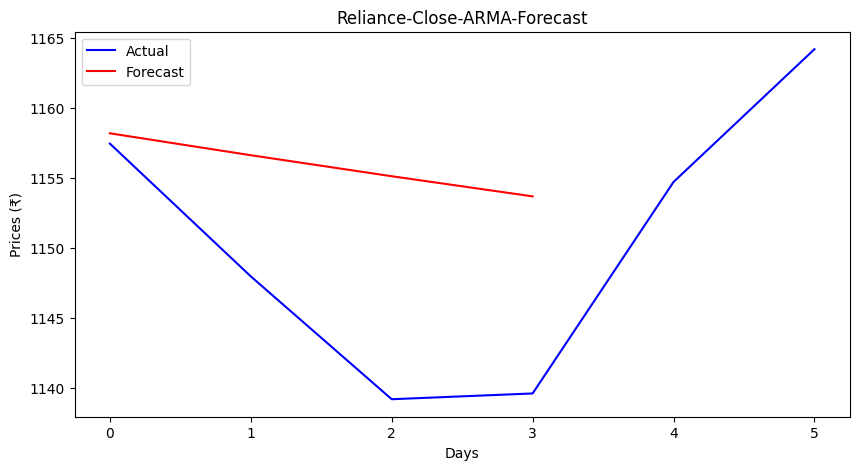

In [35]:
import matplotlib.pyplot as plt
plt.figure(figsize=(10,5))

# actual_stock_price_test_oriA has only 6 rows (index 0-5), so no slicing needed
plt.plot(actual_stock_price_test_oriA.values, color='blue', label="Actual")
plt.plot(forecast_stock_price_test_oriF.values, color='red', label="Forecast")

plt.title("Reliance-Close-ARMA-Forecast")
plt.xlabel("Days")
plt.ylabel("Prices (₹)")
plt.legend()
plt.show()